### We want to study the lowest Rayleigh number case $10^5$

We start with the highest resolution possible and then go lower and lower

In [1]:
using Oceananigans
using CairoMakie
using NCDatasets
using Statistics
using Printf
using LsqFit

In [2]:
using TopographicHorizontalConvection:get_η
using TopographicHorizontalConvection:is_kolmogorov_resolved
using TopographicHorizontalConvection:get_ratio
using TopographicHorizontalConvection:compute_statistics

In [3]:
using TopographicHorizontalConvection:dissipation_analysis
using TopographicHorizontalConvection:streamfunction_subplots
using TopographicHorizontalConvection:diss_norm_eq_subplots

In [8]:
ds_696 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/696_87/oceanostics.nc"));
ds_696_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/696_87/buoyancy.nc"));
ds_696_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/696_87/velocities.nc"));

ds_686 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/686_77/oceanostics.nc"))
ds_686_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/686_77/buoyancy.nc"));
ds_686_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/686_77/velocities.nc"))

ds_600 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/600_75/oceanostics.nc"))
ds_600_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/600_75/buoyancy.nc"))
ds_600_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/600_75/velocities.nc"))

ds_550 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/550_69/oceanostics.nc"))
ds_550_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/550_69/buoyancy.nc"))
ds_550_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/550_69/velocities.nc"))

ds_500 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/500_63/oceanostics.nc"))
ds_500_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/500_63/buoyancy.nc"))
ds_500_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/500_63/velocities.nc"))

ds_450 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/450_56/oceanostics.nc"))
ds_450_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/450_56/buoyancy.nc"))
ds_450_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/450_56/velocities.nc"))

ds_400 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/400_50/oceanostics.nc"))
ds_400_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/400_50/buoyancy.nc"))
ds_400_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/400_50/velocities.nc"))

ds_350 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/350_44/oceanostics.nc"))
ds_350_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/350_44/buoyancy.nc"))
ds_350_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/350_44/velocities.nc"))

ds_300 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/300_38/oceanostics.nc"))
ds_300_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/300_38/buoyancy.nc"))
ds_300_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/300_38/velocities.nc"))

ds_250 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/250_31/oceanostics.nc"))
ds_250_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/250_31/buoyancy.nc"))
ds_250_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/250_31/velocities.nc"))

ds_200 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/200_25/oceanostics.nc"))
ds_200_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/200_25/buoyancy.nc"))
ds_200_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/200_25/velocities.nc"))

ds_150 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/150_19/oceanostics.nc"))
ds_150_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/150_19/buoyancy.nc"))
ds_150_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/150_19/velocities.nc"))

ds_100 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/100_13/oceanostics.nc"))
ds_100_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/100_13/buoyancy.nc"))
ds_100_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/100_13/velocities.nc"))

ds_50 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/50_6/oceanostics.nc"))
ds_50_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/50_6/buoyancy.nc"))
ds_50_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/50_6/velocities.nc"))

ds_20 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/20_3/oceanostics.nc"))
ds_20_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/20_3/buoyancy.nc"))
ds_20_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/20_3/velocities.nc"))

ds_10 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/10_2/oceanostics.nc"))
ds_10_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/10_2/buoyancy.nc"))
ds_10_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/gridtesting/10_2/velocities.nc"))

ds_list = [ds_696, ds_686, ds_600, ds_550, ds_500, ds_450, ds_400, ds_350, ds_300, ds_250, ds_200, ds_150, ds_100, ds_50, ds_20, ds_10]
ds_bs = [ds_696_b, ds_686_b, ds_600_b, ds_550_b, ds_500_b, ds_450_b, ds_400_b, ds_350_b, ds_300_b, ds_250_b, ds_200_b, ds_150_b, ds_100_b, ds_50_b, ds_20_b, ds_10_b]
ds_vs = [ds_696_v, ds_686_v, ds_600_v, ds_500_v, ds_500_v, ds_450_v, ds_400_v, ds_350_v, ds_300_v, ds_350_v, ds_200_v, ds_150_v, ds_100_v, ds_50_v, ds_20_v, ds_10_v];


In [ ]:
# import relevant data from the files 

epsilons = []
nus = []
Δxs = []

for ds in ds_list
    ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
    ν = ds.attrib["ν"]
    Δx = ds.attrib["Lx"] / ds.attrib["Nx"]
    push!(epsilons, ε)
    push!(nus, ν)
    push!(Δxs, Δx)
end

ηs = []
eta_mins = []
for (i,j) in zip(epsilons, nus)
    η = get_η(i, j)
    η_min = minimum(x for x in η if x > 0)
    push!(ηs, η)
    push!(eta_mins, η_min)
end

In [ ]:
for (i,j,k) in zip(Δxs, epsilons, nus)
    resolved, eta_min = is_kolmogorov_resolved(i,j,k)
    if resolved
        @printf("The kolmogorov scale is resolved with Δx=%.5f and η_min = %.5f\n", i, eta_min)
    else
        @printf("The kolmogorov scale is NOT resolved with Δx=%.5f and η_min = %.5f\n", i, eta_min)
    end
end

The kolmogorov scale is resolved with Δx=0.01149 and η_min = 0.01323
The kolmogorov scale is resolved with Δx=0.01166 and η_min = 0.01367
The kolmogorov scale is resolved with Δx=0.01333 and η_min = 0.01381
The kolmogorov scale is NOT resolved with Δx=0.01455 and η_min = 0.01422
The kolmogorov scale is NOT resolved with Δx=0.01600 and η_min = 0.01462
The kolmogorov scale is NOT resolved with Δx=0.01778 and η_min = 0.01526
The kolmogorov scale is NOT resolved with Δx=0.02000 and η_min = 0.01574
The kolmogorov scale is NOT resolved with Δx=0.02286 and η_min = 0.01665
The kolmogorov scale is NOT resolved with Δx=0.02667 and η_min = 0.01754
The kolmogorov scale is NOT resolved with Δx=0.03200 and η_min = 0.01839
The kolmogorov scale is NOT resolved with Δx=0.04000 and η_min = 0.02039
The kolmogorov scale is NOT resolved with Δx=0.05333 and η_min = 0.02262
The kolmogorov scale is NOT resolved with Δx=0.08000 and η_min = 0.02669
The kolmogorov scale is NOT resolved with Δx=0.16000 and η_min 

In [ ]:
#function to calculate the statisics of Δx\η to understand how well or poorly our simulation is resolving η

function compute_r_stat(Δx, ε, ν)
    r = get_ratio(Δx, ε, ν)

    r_min = minimum(r)
    r_max = maximum(r)
    r_median = median(r)
    r_mean = mean(r)
    r_95 = quantile(r, 0.95)

    frac_r_greater_than_1 = count(>(1.0), r) / length(r)

    #return Dict(
    #    "r_min" => r_min,
    #    "r_max" => r_max,
    #    "r_median" => r_median,
    #    "r_mean" => r_mean,
    #    "r_95" => r_95,
    #    "frac_r_greater_than_1" => frac_r_greater_than_1
    #)
    return r_max, r_mean, frac_r_greater_than_1
end

compute_r_stat (generic function with 1 method)

### How do the dissipation parameters $\varepsilon$ and $\chi$ averaged over the equilibrium time visually change as we degrade the resolution?

1.7661317124642175-Inf1.6761278442678966-Inf1.706645814910936-Inf1.522930037760265-Inf1.717972706284493-Inf1.654393808553903-Inf1.5635931248503396-Inf1.316479625171294-Inf1.4442115121899815-Inf1.3210416953890634-Inf1.182575224338219-Inf1.0021116962373995-Inf0.892113153522924-Inf0.4698946906394559-Inf-0.3160058912108265-2.5090528930842315-0.6931340982062347-1.7393911912664595

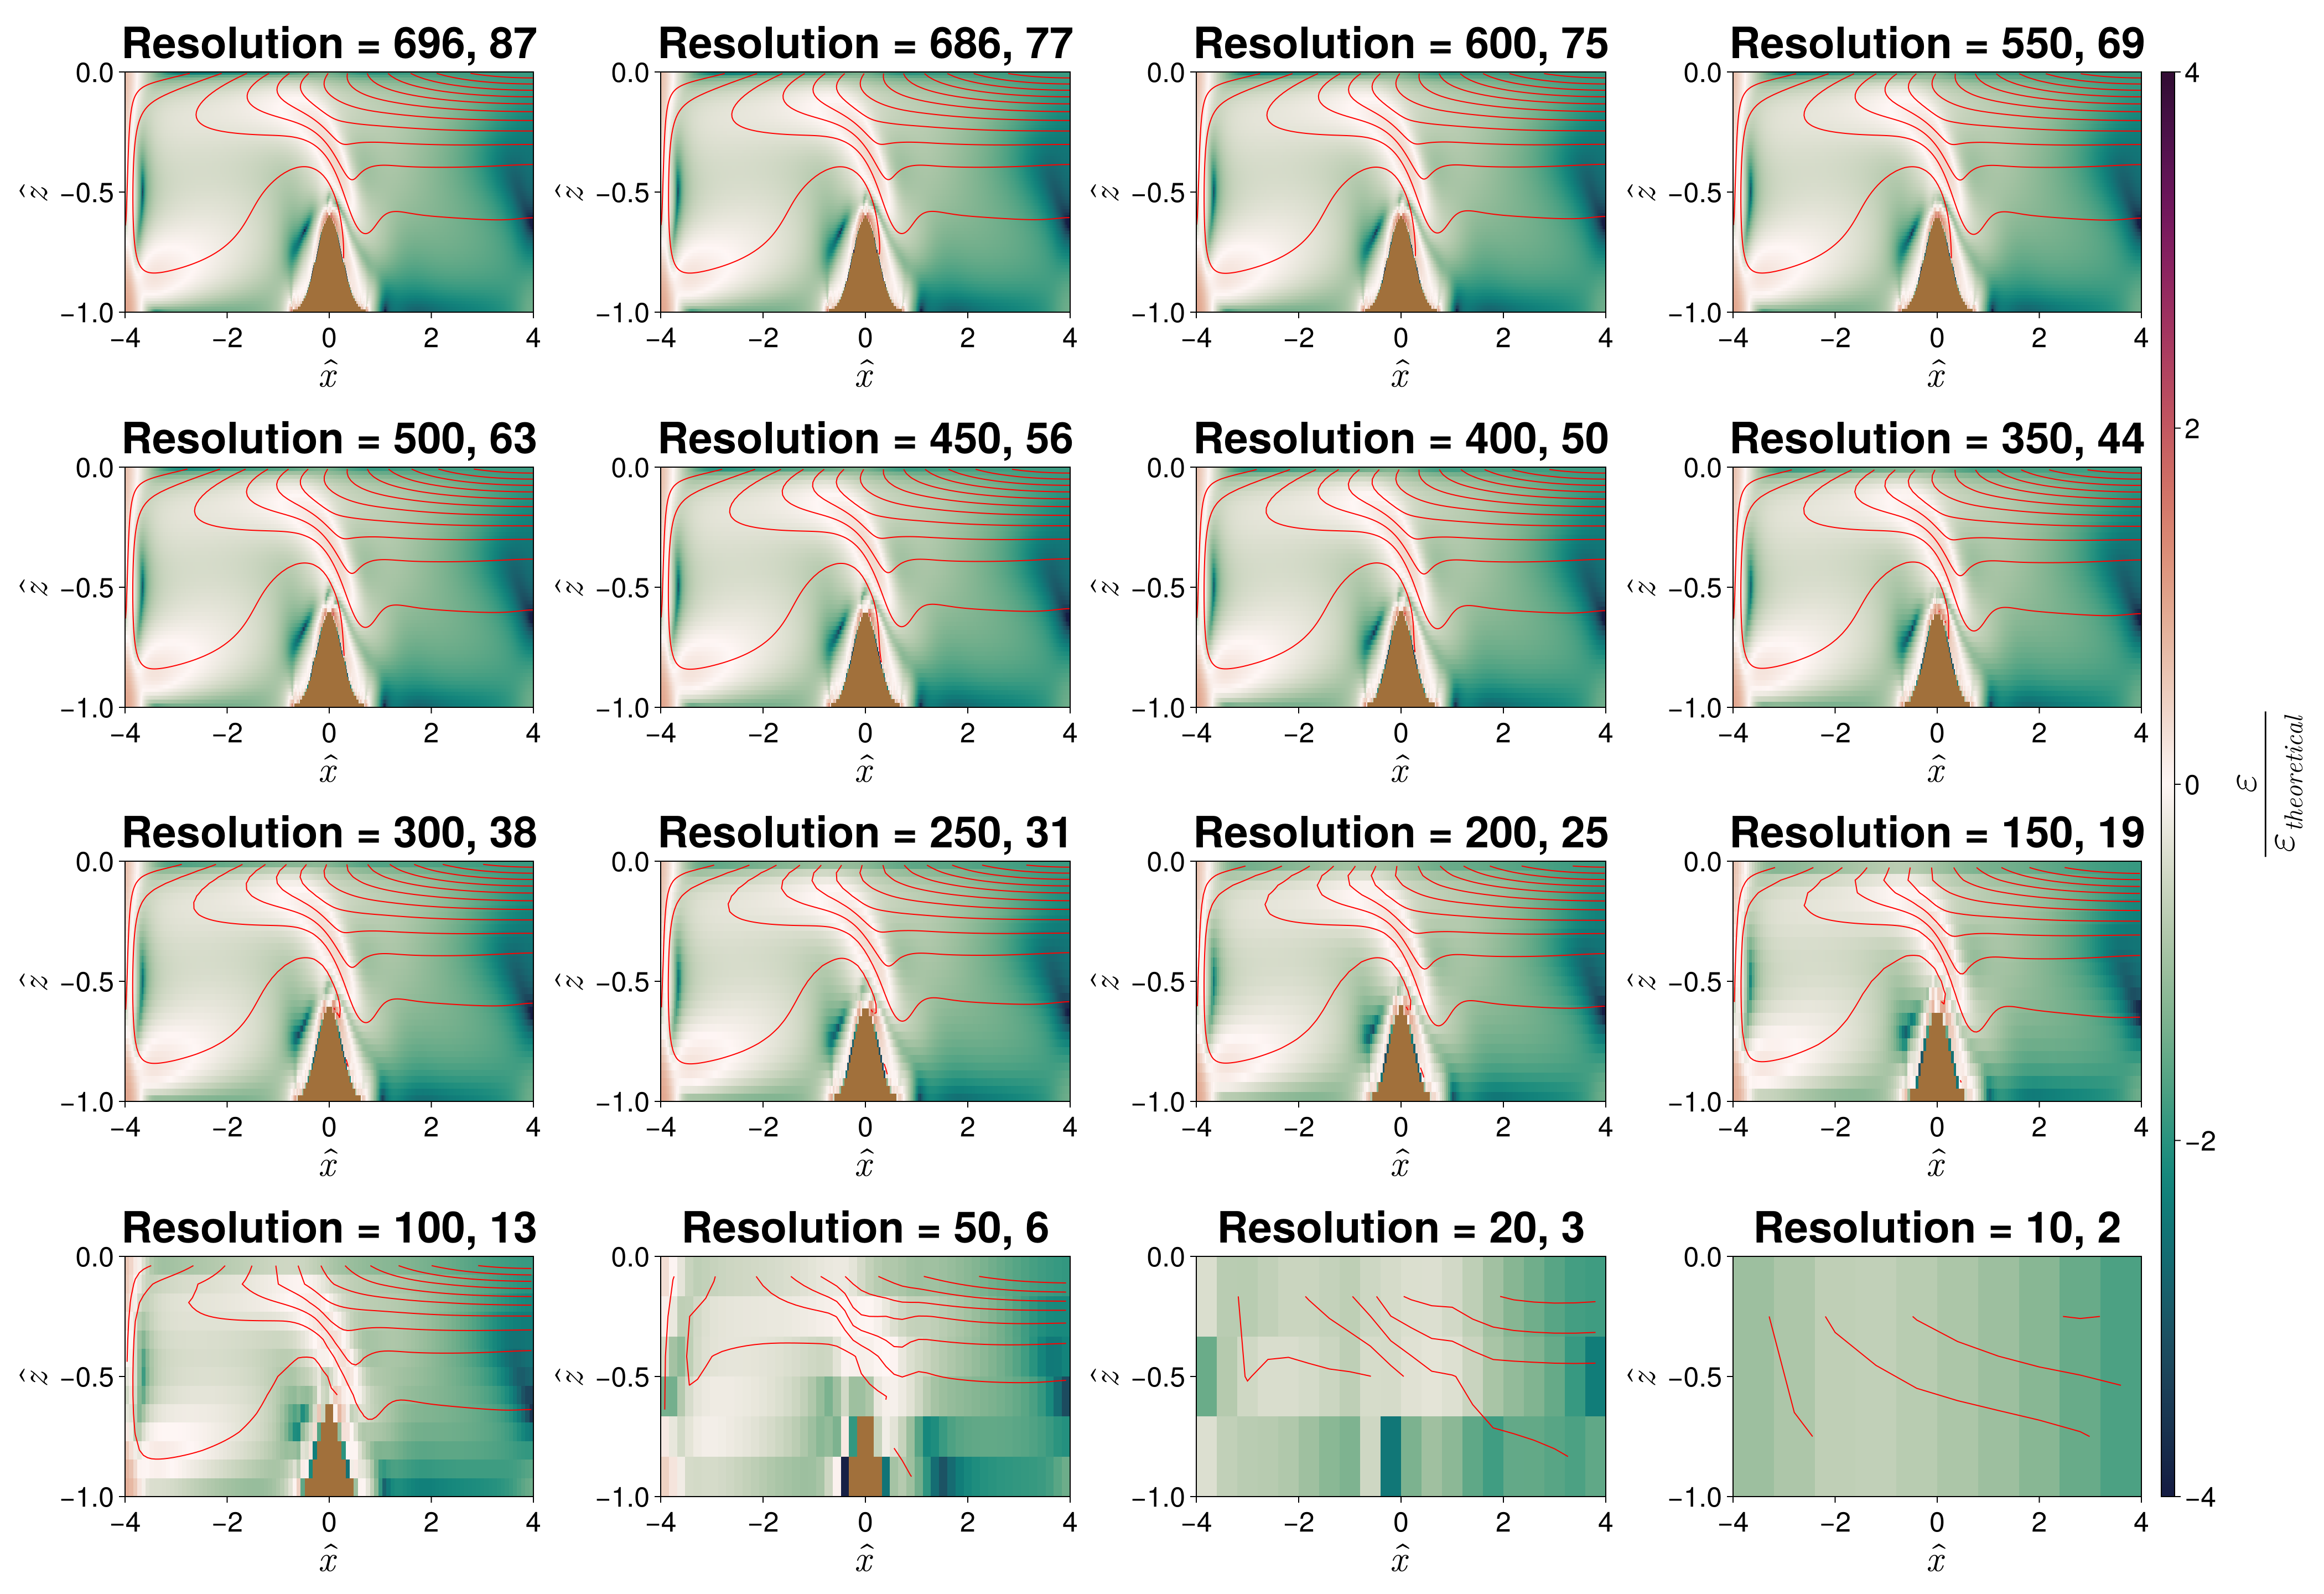

In [80]:
epsilon_compare = diss_norm_eq_subplots(ds_list, ds_bs, "ε", (-4, 4), cols=4)

-1.2060920751602633-Inf-1.2061119041321822-Inf-1.2051743375818034-Inf-1.2069956881794848-Inf-1.2038781111437489-Inf-1.2029059619041498-Inf-1.2054799569586576-Inf-1.2091546930431913-Inf-1.205625535104868-Inf-1.205644280047197-Inf-1.2134676914069231-Inf-1.2284942981390752-Inf-1.2375371730100222-Inf-1.3686049442126476-Inf-1.7682677015170738-Inf-1.9571236580262314-5.819363222724059

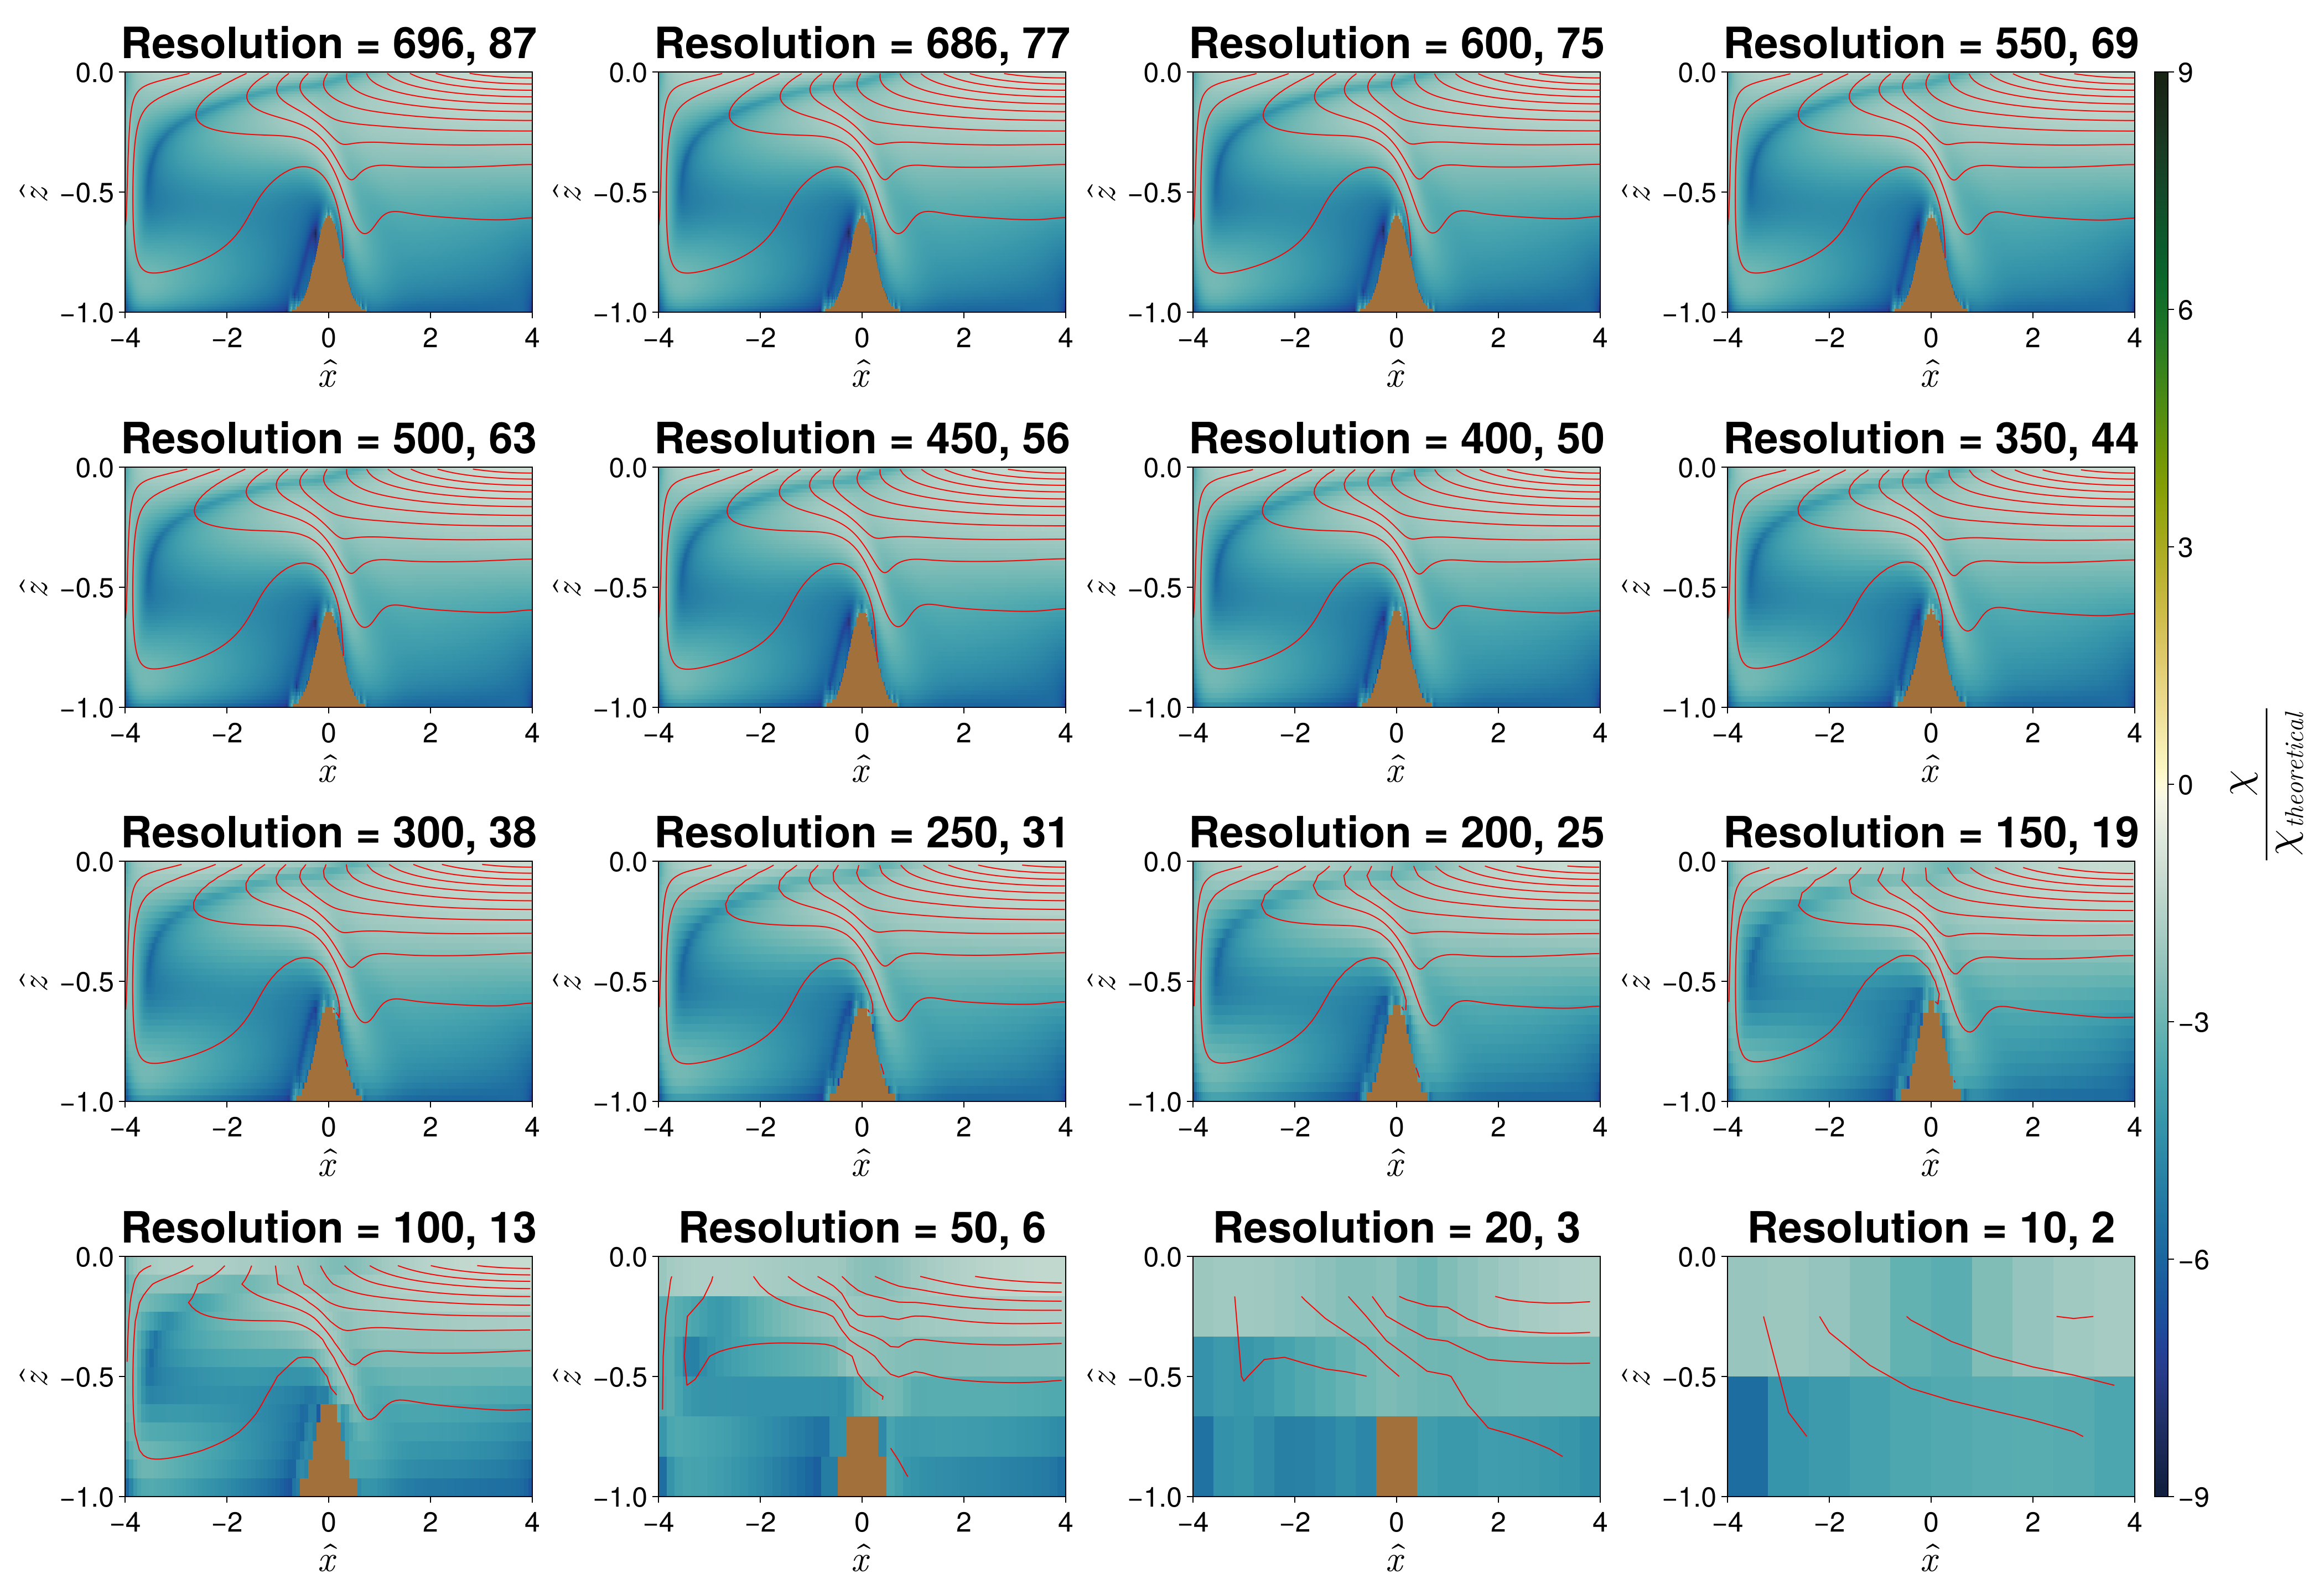

In [21]:
epsilon_compare = diss_norm_eq_subplots(ds_list, ds_bs, "χ", (-9, 9), cols=4)

### Let's look at this further, plot the difference between the simulations on a heatmap. You can't visualize the difference very well on these plots so plotting the difference can help actually visualize the difference. 

will need to do 2d interpolation 

In [344]:
function compare_datasets(ds_high, ds_low, var, CR, CR_diff)
    # High-resolution dataset 
    Nx_high, Nz_high = ds_high.attrib["Nx"], ds_high.attrib["Nz"]
    x_high = ds_high["xC"][5:end-4]
    z_high = ds_high["zC"][5:end-4]
    time_high = ds_high["time"][:]
    eq_start_high = round(Int, 0.9 * size(time_high, 1))

    var_high = ds_high[var][5:end-4, 1, 5:end-4, eq_start_high:end]

    #create a wet mask so hills are a different color 
    wet_high = var_high .!= 0
    wet_masked_high = Float64.(copy(wet_high))
    wet_masked_high[wet_high] .= NaN

    var_eq_avg_high = nanmean(var_high, dims=3)
    var_eq_avg_2d_high = dropdims(var_eq_avg_high; dims=3)

    var_theory_high = dissipation_analysis(ds_high, var)[1]
    var_norm_high = var_eq_avg_2d_high ./ var_theory_high

    # High-res coordinate grids (Nx, Nz)
    X_high = repeat(reshape(x_high, :, 1), 1, Nz_high)
    Z_high = repeat(reshape(z_high, 1, :), Nx_high, 1)

    # Low-resolution dataset
    Nx_low, Nz_low = ds_low.attrib["Nx"], ds_low.attrib["Nz"]
    x_low = ds_low["xC"][5:end-4]
    z_low = ds_low["zC"][5:end-4]
    time_low = ds_low["time"][:]
    eq_start_low = round(Int, 0.9 * size(time_low, 1))

    var_low = ds_low[var][5:end-4, 1, 5:end-4, eq_start_low:end]
    var_eq_avg_low = nanmean(var_low, dims=3)
    var_eq_avg_2d_low = dropdims(var_eq_avg_low; dims=3)

    var_theory_low = dissipation_analysis(ds_low, var)[1]
    var_norm_low = var_eq_avg_2d_low ./ var_theory_low

    # Interpolate low res field onto high res grid
    itp = Interpolations.extrapolate(
              Interpolations.interpolate(
                  (x_low, z_low),
                  var_norm_low,
                  Interpolations.Gridded(Interpolations.Linear())
              ),
              Interpolations.Flat()
          )

    var_low_on_high = [itp(xx, zz) for (xx, zz) in zip(vec(X_high), vec(Z_high))]
    var_low_on_high = reshape(var_low_on_high, size(var_norm_high))

    # Compute difference ---
    var_diff = var_norm_high .- var_low_on_high

    # --- Apply log10 scaling ---
    log_var_high = log10.(var_norm_high)
    log_var_low_on_high = log10.(var_low_on_high)
    #log_var_diff = log10.(abs.(var_diff) .+ 1e-12) # avoid log(0)
    var_difference_in_logs = log_var_high .- log_var_low_on_high
#plot
    fig = Figure(size=(1500,500))
    ax1 = Axis(fig[1,1], title="High Resolution: ($Nx_high, $Nz_high)", xlabel = L"\hat{x}", ylabel=L"\hat{z}")
    
    if var == "χ"
        color = :delta
        titlestring = "χ Comparison Across Resolutions"
    elseif var == "ε"
        color = :curl
        titlestring = "ε Comparison Across Resolutions"
    end


    hm1 = heatmap!(ax1, x_high, z_high, log_var_high, colorrange = CR, colormap=color)
    #add hills as diff color to each hm
    hm_hill = heatmap!(ax1, x_high, z_high, wet_masked_high[:,:,1], colormap=:turbid)
    Colorbar(fig[1, 2], hm1, label=L"\log_{10}(\frac{%$var}{%$(var)_{theoretical}})")

    ax2 = Axis(fig[1,3], title="Interpolated Low Resolution: ($Nx_low, $Nz_low)", xlabel = L"\hat{x}", ylabel=L"\hat{z}")
    hm2 = heatmap!(ax2, x_high, z_high, log_var_low_on_high, colorrange = CR, colormap=color)
    hm_hill2 = heatmap!(ax2, x_high, z_high, wet_masked_high[:,:,1], colormap=:turbid)
    Colorbar(fig[1, 4], hm2, label=L"\log_{10}(\frac{%$(var)_{interp}}{%$(var)_{theoretical}})")

    ax3 = Axis(fig[1,5], title="Difference (High-Low)", xlabel = L"\hat{x}", ylabel=L"\hat{z}")
    hm3 = heatmap!(ax3, x_high, z_high, var_difference_in_logs, colorrange = CR_diff, colormap=:balance)
    hm_hill3 = heatmap!(ax3, x_high, z_high, wet_masked_high[:,:,1], colormap=:turbid)
    Colorbar(fig[1, 6], hm3, label=L"\Delta(\log_{10}({%$var}))")

    fig[0, :] = Label(fig, titlestring, fontsize = 18, tellwidth = false)

    return fig
    #return var_diff, var_norm_high, var_low_on_high, x_high, z_high
end


compare_datasets (generic function with 3 methods)

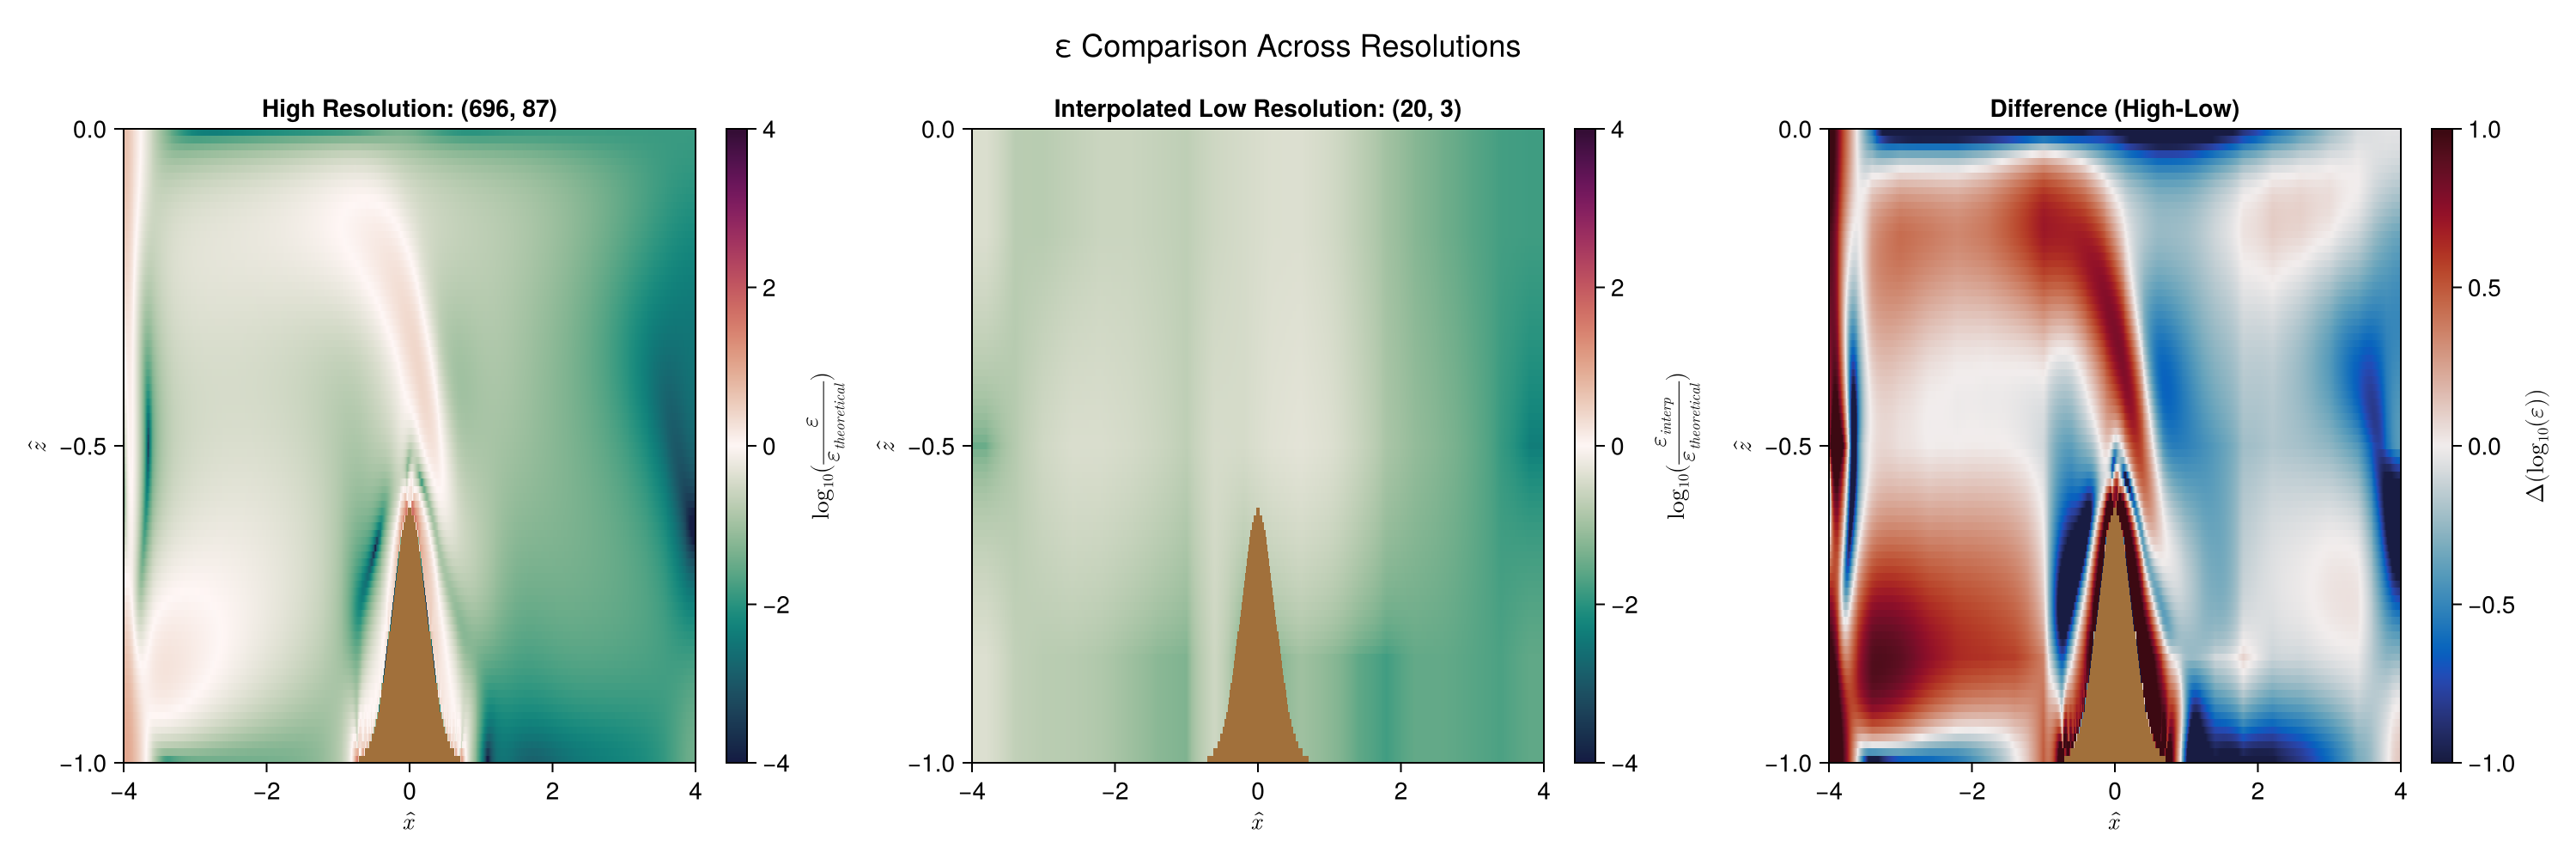

In [345]:
compare_datasets(ds_696, ds_20, "ε", (-4, 4), (-1,1))

#### This figure shows how features that we want to analyze change with degraded resolution. The first panel shows log10 of time averaged (over equilibrium period), normalized kinetic energy dissipation of true kolmogorov resoloved simulation. The second panel shows the results from the low resolution simulations interpolated in two dimensions onto the high resolution grid. The third panel shows the difference in log epsilons. The red regions mean the high resolution results are 10x larger than low resolution, therefore dissipation is being underestimated. The darker blue regions mean the high resolution results are 10x smaller than low resolution, implying dissipation is being overestimated. In this figure there are clearly three distinct regions where the low resolution is really underestimating dissipation: descending plume, overflow, and bottom boundary layer on the hill. There are corresponding regions over overestimating dissipation because these features are spread out too much. 

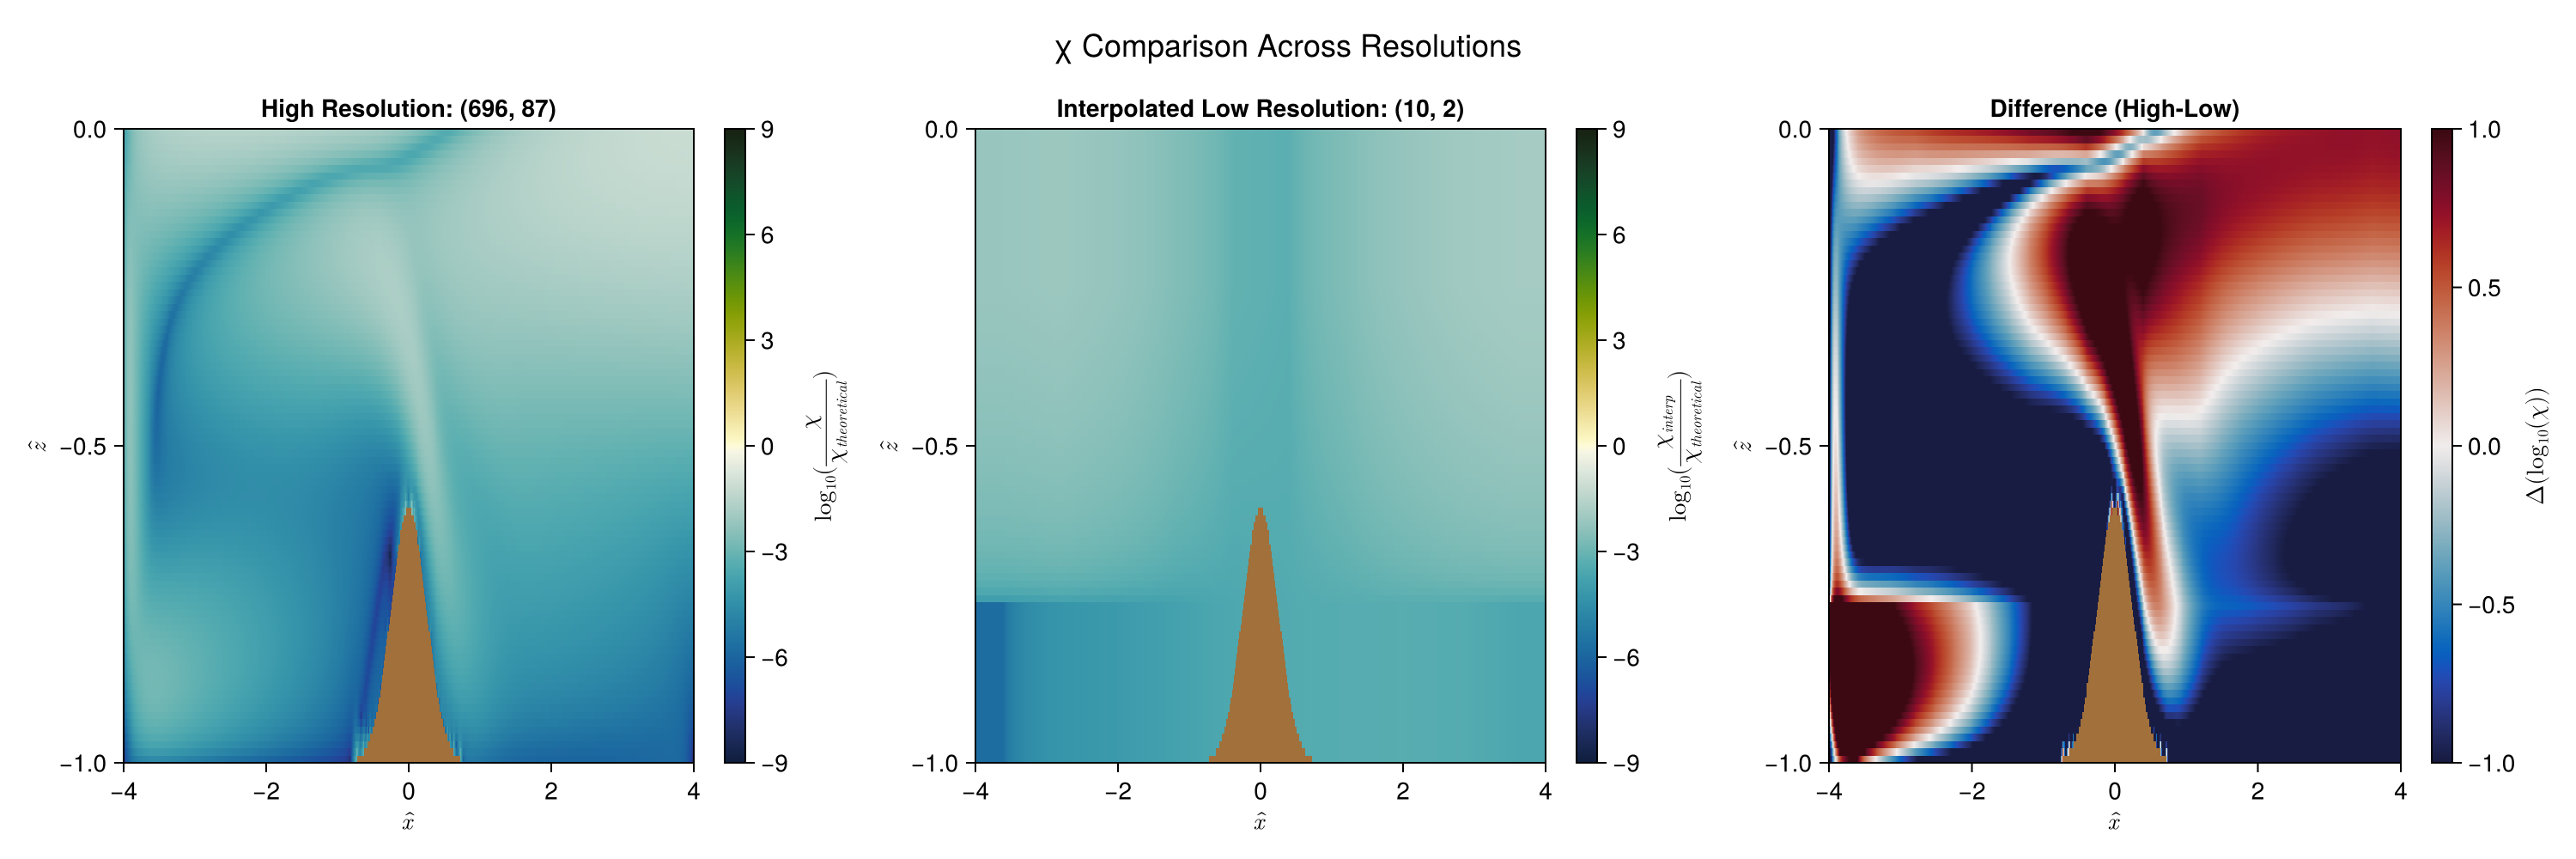

In [346]:
compare_datasets(ds_696, ds_10, "χ", (-9, 9), (-1, 1))

#### This is a similar figure, this time analyzing buoyancy dissipation. Buoyancy dissipation is clearly being underestimated in the descending plume region, the overflow (over the hill) region, and the buoyancy boundary layer (top) regions. 

#### Now we want to see how the resolution changes with the $\varepsilon$ and $\chi$ constraint plot that we analyzed over the summer

[200000.0, 2.0e6, 1.0e7, 2.0e7]

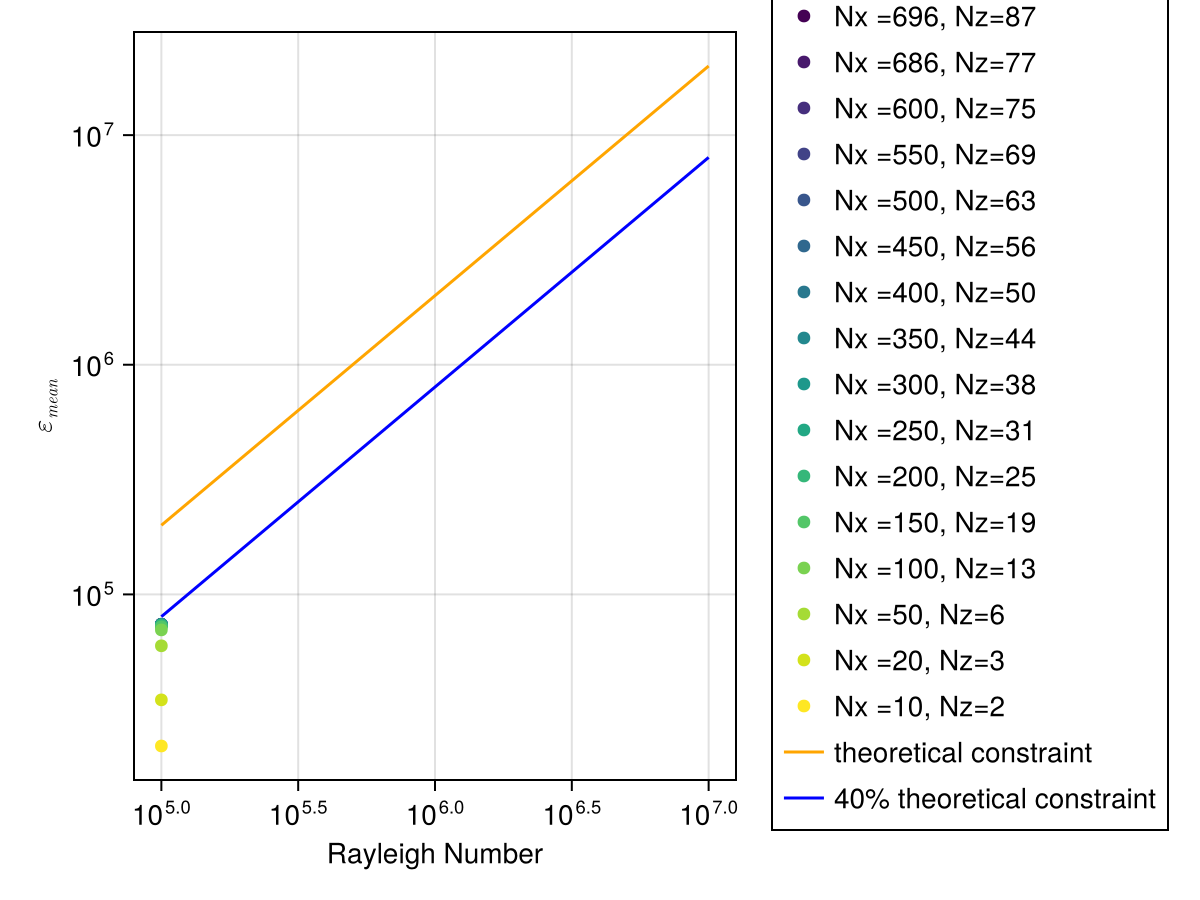

In [70]:
using TopographicHorizontalConvection:dissipation_analysis
using ColorSchemes

Ras = [1e5, 1e6, 5e6, 1e7]
ε_means = []
χ_means = []
Nxs = []
Nzs = []
χ_theories_from_brain = 4.57 .* 2^(7/3) .* Ras.^(7/3)
ε_theories_from_brain = 2 .* Ras
print(ε_theories_from_brain)

for ds in ds_list
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Nx = ds.attrib["Nx"]
    Nz = ds.attrib["Nz"]
    e_time_mean = dissipation_analysis(ds, "ε")[3] ./ (ν^3 / H^4)
    chi_time_mean = dissipation_analysis(ds, "χ")[3] ./ (κ^5 / H^8)

    push!(ε_means, e_time_mean)
    push!(χ_means, chi_time_mean)
    push!(Nxs, Nx)
    push!(Nzs, Nz)

end
f_ε = Figure()
ax = Axis(f_ε[1,1],
            xscale = log10,
            yscale = log10, 
            xlabel = "Rayleigh Number",
            ylabel = L"\varepsilon_{mean}"
)

Ra_1e5 = fill(1e5, length(ε_means))

colors = [get(ColorSchemes.viridis, i) for i in range(0, 1, length=16)]

for (i, j, k, l) in zip(ε_means, Nxs, Nzs, colors)
    scatter!(ax, 1e5, i, label="Nx =$(j), Nz=$(k)", color= l)
end
#scatter!(ax, Ra_1e5[4:end], ε_means[4:end])


lines!(ax, Ras, ε_theories_from_brain, color = :orange, label="theoretical constraint")
lines!(ax, Ras, ε_theories_from_brain * 0.4, color = :blue, label="40% theoretical constraint")
Legend(f_ε[1,2], ax)

f_ε

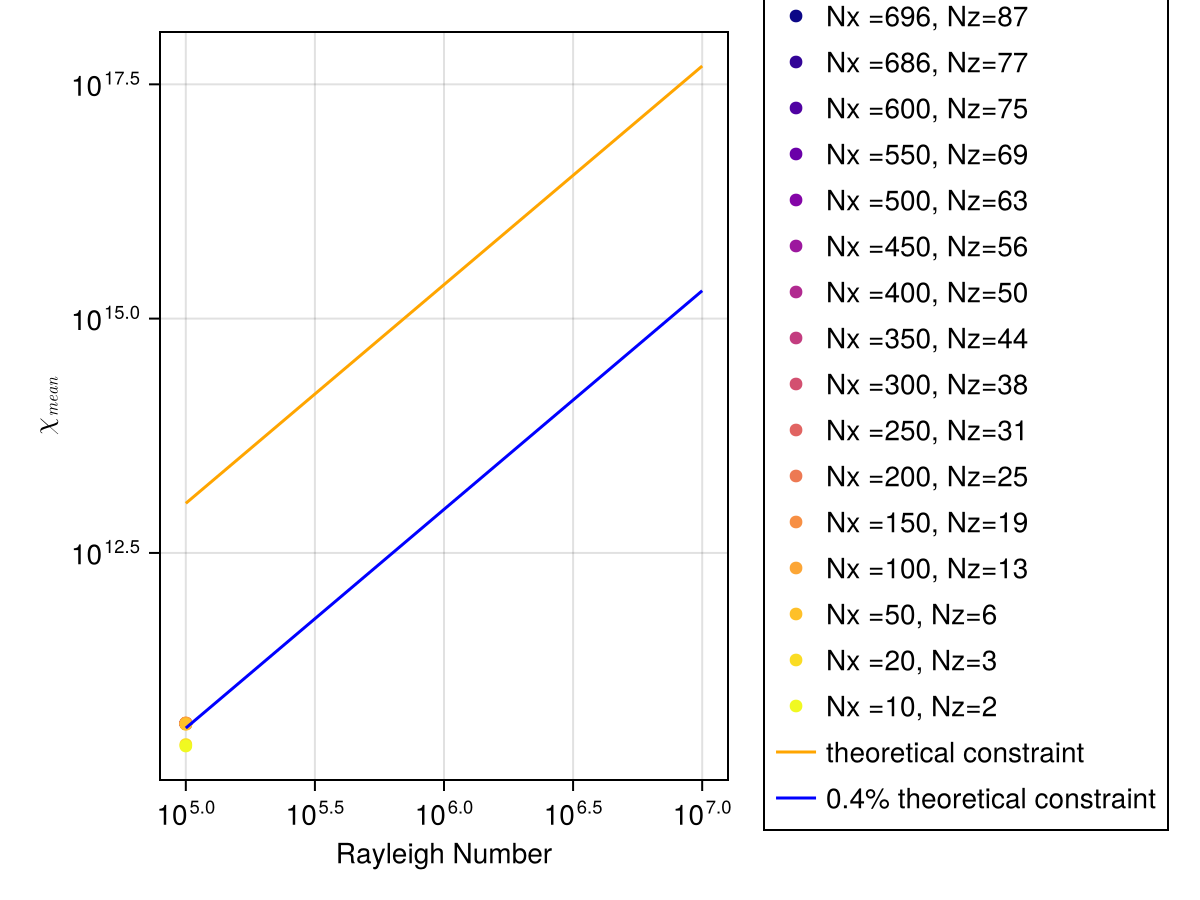

In [147]:
f_chi = Figure()
ax = Axis(f_chi[1,1],
            xscale = log10,
            yscale = log10, 
            xlabel = "Rayleigh Number",
            ylabel = L"\chi_{mean}"
)

colors_2 = [get(ColorSchemes.plasma, i) for i in range(0, 1, length=16)]

for (i, j, k, l) in zip(χ_means, Nxs, Nzs, colors_2)
    scatter!(ax, 1e5, i, label="Nx =$(j), Nz=$(k)", color= l)
end
#scatter!(ax, Ra_1e5[1], ε_means[14])


lines!(ax, Ras, χ_theories_from_brain, color = :orange, label="theoretical constraint")
lines!(ax, Ras, χ_theories_from_brain * 0.004, color = :blue, label="0.4% theoretical constraint")
Legend(f_chi[1,2], ax)

f_chi

#### cool! so the results show that the points for different resolutions all converge to basically the same value until the lowest 2 or three simulations. This implies that we don't necessarily need to resolve the kolmogorov scale perfectly in order to predict the correct physics. 

### How do the nondimensional, volume averaged, time mean (over eq period) dissipation parameters: $\overline{\langle \varepsilon \rangle} / \varepsilon_0 $ and $\overline{\langle \chi \rangle } / \chi_0$ change as the horizontal resolution of the simulation is increased? How quickly do these parameters converge?

To answer this we plot the calculated $\varepsilon_{means}$ and $\chi_{means}$ as a function of the resolution $N_x$:

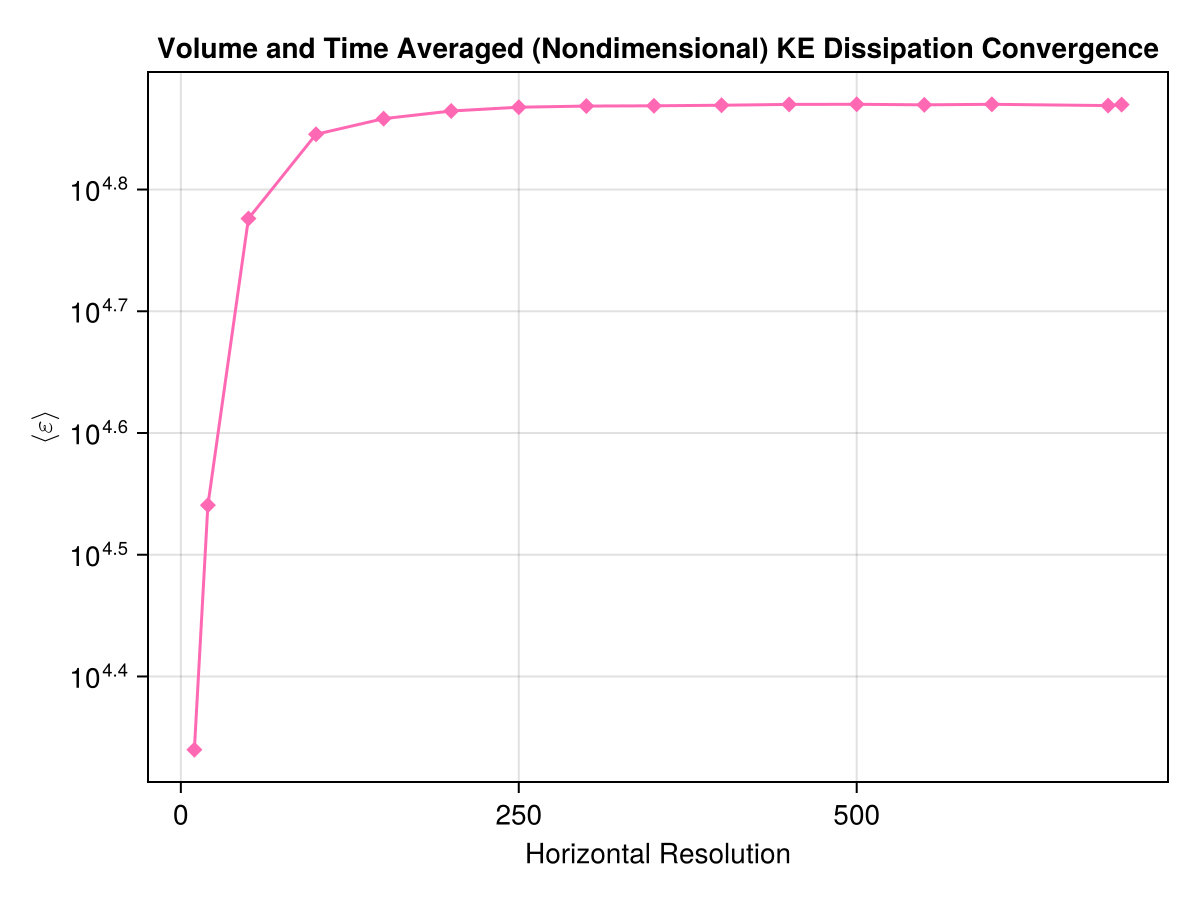

In [124]:
f_e_res = Figure()
ax_er = Axis(f_e_res[1,1], 
            xlabel = "Horizontal Resolution", 
            ylabel = L"\langle \varepsilon \rangle",
            yscale = log10,
            title = "Volume and Time Averaged (Nondimensional) KE Dissipation Convergence")
scatterlines!(ax_er, Nxs, ε_means, marker=:diamond, color=:hotpink)

f_e_res


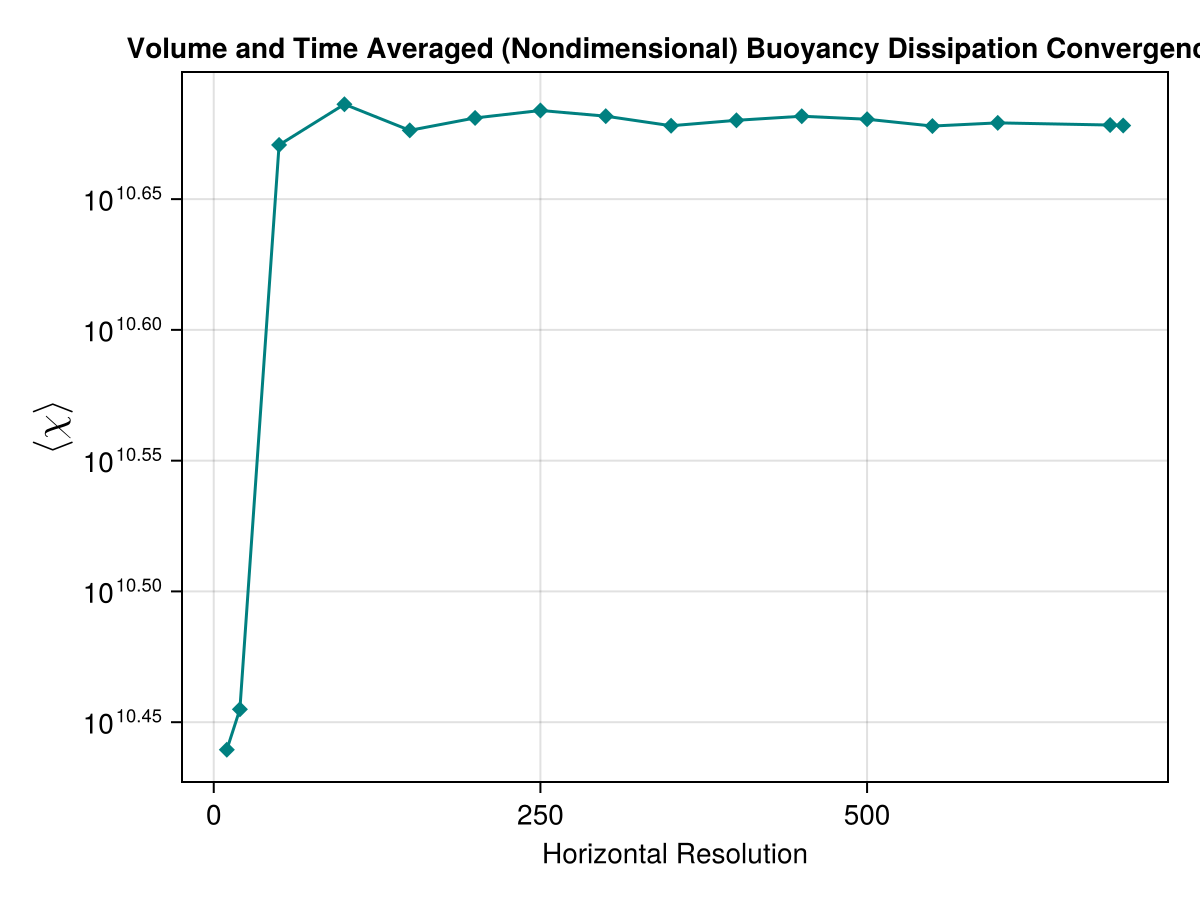

In [127]:
f_c_res = Figure()
ax_cr = Axis(f_c_res[1,1], 
            xlabel = "Horizontal Resolution", 
            ylabel = L"\langle \chi \rangle",
            yscale = log10,
            title = "Volume and Time Averaged (Nondimensional) Buoyancy Dissipation Convergence")
ax_cr.ylabelsize = 20
scatterlines!(ax_cr, Nxs, χ_means, marker=:diamond, color=:teal)

f_c_res

### The result is promising!!! The result converges after the 4th simulation for $\varepsilon$ and after the third simulation for $\chi$. So around $N_x, N_z = 100, 13$ and $N_x, N_z = 50, 6$ respectively. 

### Analyzing the $r(x,t) = \eta(x,t) / \Delta x $ metrics versus the grid resolution

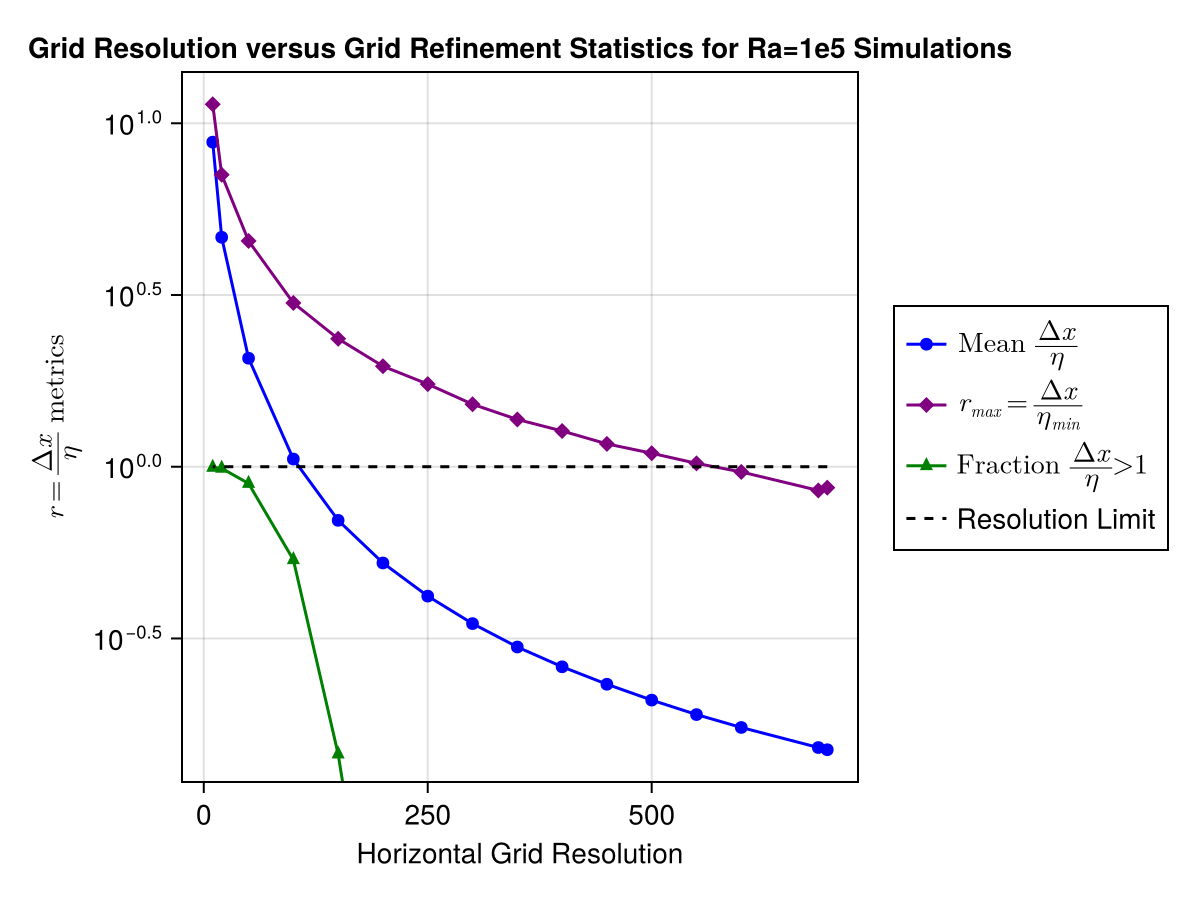

In [112]:
r_maxes = []
r_means = []
r_gt1 = []

for (i,j,k) in zip(Δxs, epsilons, nus)
    max, mean, gt1 = compute_r_stat(i, j, k)
    push!(r_maxes, max)
    push!(r_means, mean)
    push!(r_gt1, gt1)
end

f_r = Figure()
ax_r = Axis(f_r[1,1], 
            yscale = log10,
            xlabel = "Horizontal Grid Resolution", 
            ylabel = L"$r = \frac{\Delta x}{\eta}$ metrics",
            title = "Grid Resolution versus Grid Refinement Statistics for Ra=1e5 Simulations")

scatterlines!(ax_r, Nxs, r_means, marker=:circle, color=:blue, label=L"\text{Mean } \frac{\Delta x}{\eta}")
scatterlines!(ax_r, Nxs, r_maxes, marker=:diamond, color=:purple, label=L"r_{max} = \frac{\Delta x}{\eta_{min}}")
scatterlines!(ax_r, Nxs, r_gt1, marker=:utriangle, color=:green, label=L"\text{Fraction } \frac{\Delta x}{\eta} > 1")

lines!(ax_r, Nxs, ones(16), color=:black, linestyle=:dash, label="Resolution Limit")
Legend(f_r[1,2], ax_r)

f_r



### The plots of $\overline{\langle \varepsilon \rangle }$ and $\overline{\langle \chi \rangle} $ were averaged over space and time. The overline denotes a time average **over the equilibrium period (last ten percent of runtime)**. Just as a check I'll make a plot showing that $\eta$ is infact equilibrated over the simulation. 

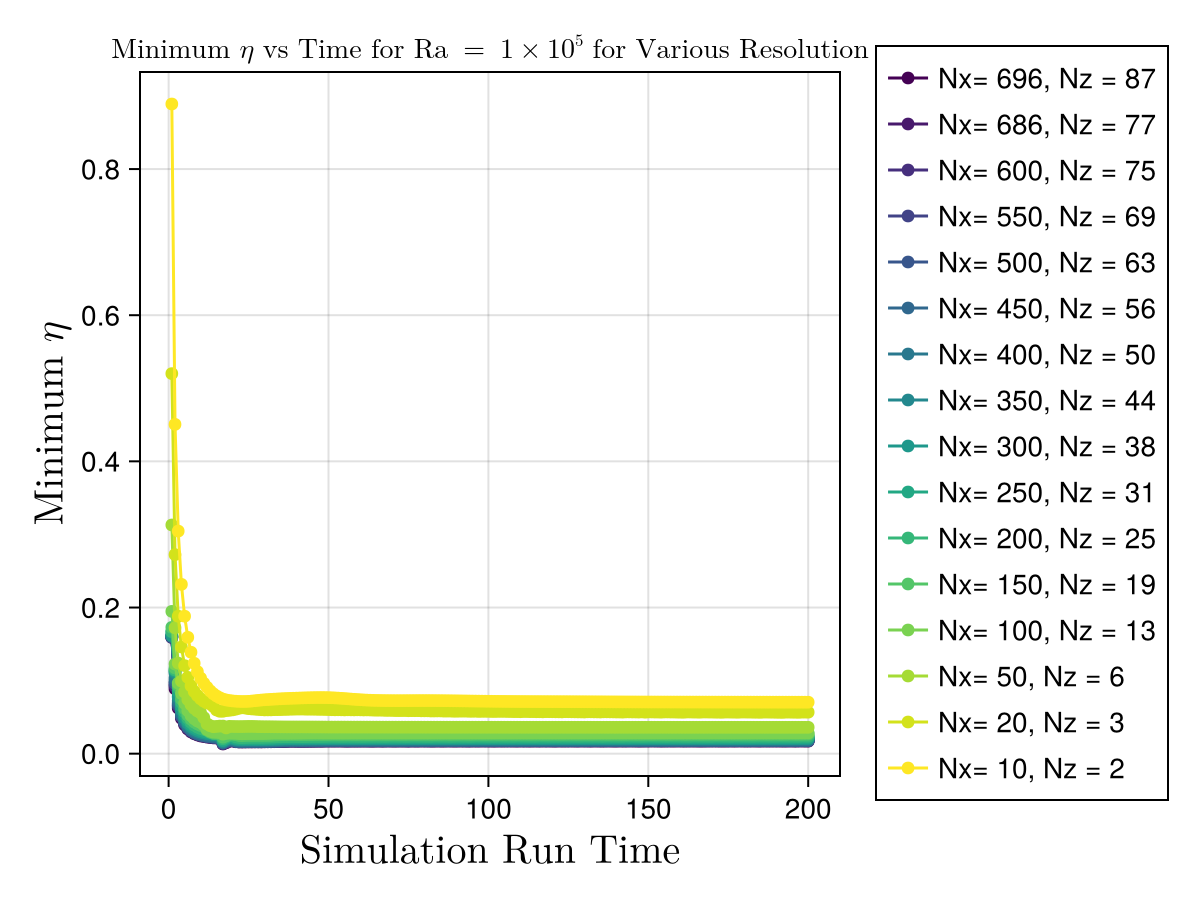

In [155]:
# I already have an array that holds all 16 η(x,t)
# I want to plot the minimum η as a function of time
η_min_time_arrs = []

f_eta_min = Figure()
ax_em = Axis(f_eta_min[1,1],
                xlabel = L"\text{Simulation Run Time}", 
                ylabel = L"\text{Minimum } \eta", 
                title = L"\text{Minimum } \eta \text{ vs Time for Ra = } 1 \times 10^5 \text{ for Various Resolution}"
                )
ax_em.ylabelsize = 20
ax_em.xlabelsize =20
ax_em.titlesize = 14

colors = [get(ColorSchemes.viridis, i) for i in range(0, 1, length=16)]

for (i, j, k, l) in zip(ηs, colors, Nxs, Nzs)
    η_min_vs_time = minimum(i, dims=(1,2))[1, 1, 2:end]
    push!(η_min_time_arrs, η_min_vs_time)
    scatterlines!(ax_em, η_min_vs_time, label="Nx= $(k), Nz = $(l)", color = j)
end

Legend(f_eta_min[1,2], ax_em)
f_eta_min
    